# Training with Cleaned Dataset and EDL Type 2
A notebook for training an EfficientNet B3 model with Evidential Deep Learning (EDL Type 2) on a 5-class diabetic retinopathy dataset.
Dataset: `cleaned_dataset` with `train`, `val`, and `test` splits and 0-4 class folders.

## Execution Flow (Single Best Path Only)
1. Run Cells 1-6
2. Run Cell 7 (k-fold training)
3. Run Cell 8 (ensemble evaluation)
4. Run Cell 9 (final checkpoint download)

This notebook now uses only the best-performance path.

## 1. Import Core Libraries

In [67]:
!pip install torch torchvision timm efficientnet-pytorch scikit-learn pandas matplotlib seaborn opencv-python

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

## 2. Define Hyperparameters and Device Configuration

In [68]:
import kagglehub

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
NUM_EPOCHS = 60
NUM_CLASSES = 5
PATIENCE = 15

# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download('dondirecto/dr-training')
print(f"Dataset path: {dataset_path}")

# Set base paths to point to the local workspace folder
BASE_DIR = os.path.join(dataset_path, 'cleaned_dataset')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

Using device: cuda
Using Colab cache for faster access to the 'dr-training' dataset.
Dataset path: /kaggle/input/dr-training


## 3. Configure Data Transforms and Loaders

In [69]:
from torch.utils.data import WeightedRandomSampler

import cv2
from PIL import Image

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = self.clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_clahe)

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.97, 1.03)),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val_test']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['val_test'])
}

train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

# Sampler weights for balancing minibatches
sampler_class_weights = 1.0 / torch.tensor(np.clip(class_counts, 1, None), dtype=torch.float)

# Explicitly protect class-2 collapse by increasing class-2 sampling pressure
CLASS2_BOOST = 1.6
sampler_class_weights[2] = sampler_class_weights[2] * CLASS2_BOOST
sample_weights = sampler_class_weights[train_targets]

# Loss weights for stronger minority-class learning (mean-normalized for stable scale)
class_weights_for_loss = torch.tensor(
    class_counts.sum() / (NUM_CLASSES * np.clip(class_counts, 1, None)),
    dtype=torch.float,
    device=device
)
class_weights_for_loss = class_weights_for_loss / class_weights_for_loss.mean()
class_weights_for_loss[2] = class_weights_for_loss[2] * 1.3
class_weights_for_loss = class_weights_for_loss / class_weights_for_loss.mean()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Original Class Counts in Train: {class_counts}")
print(f"Sampler Class Weights: {sampler_class_weights}")
print(f"Loss Class Weights (normalized): {class_weights_for_loss}")
print(f"Total Dataset Sizes: {dataset_sizes}")

Classes: ['0', '1', '2', '3', '4']
Original Class Counts in Train: [6777 3712 2568 1321 1545]
Sampler Class Weights: tensor([0.0001, 0.0003, 0.0006, 0.0008, 0.0006])
Loss Class Weights (normalized): tensor([0.3170, 0.5787, 1.0875, 1.6263, 1.3905], device='cuda:0')
Total Dataset Sizes: {'train': 15923, 'val': 2090, 'test': 2426}


## 4. Define Evidential Deep Learning (Type 2) Loss

In [70]:
# Evidential Deep Learning (EDL) Loss Functions

def relu_evidence(y):
    return torch.nn.functional.relu(y)

def exp_evidence(y):
    return torch.exp(torch.clamp(y, -10, 10))

def softplus_evidence(y):
    return torch.nn.functional.softplus(y)

def kl_divergence(alpha, num_classes, device):
    beta = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    S_alpha = torch.sum(alpha, dim=1, keepdim=True)
    S_beta = torch.sum(beta, dim=1, keepdim=True)
    lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=1, keepdim=True)
    lnB_uni = torch.sum(torch.lgamma(beta), dim=1, keepdim=True) - torch.lgamma(S_beta)
    dg0 = torch.digamma(S_alpha)
    dg1 = torch.digamma(alpha)
    kl = torch.sum((alpha - beta) * (dg1 - dg0), dim=1, keepdim=True) + lnB + lnB_uni
    return kl

def focal_cross_entropy(logits, target, class_weights=None, label_smoothing=0.1, gamma=2.0):
    ce = F.cross_entropy(
        logits,
        target,
        weight=class_weights,
        label_smoothing=label_smoothing,
        reduction='none'
    )
    pt = torch.exp(-ce)
    focal = ((1 - pt) ** gamma) * ce
    return focal.mean()

def edl_type2_loss(
    output,
    target,
    epoch_num,
    num_classes,
    annealing_step,
    device,
    class_weights=None,
    epsilon=0.1,
    ce_weight=0.7,
    kl_scale=0.01,
    focal_gamma=2.0
 ):
    """
    Hybrid loss = EDL + class-weighted focal CE.
    This reduces class collapse while keeping uncertainty modeling.
    """
    evidence = softplus_evidence(output)
    alpha = evidence + 1
    S = torch.sum(alpha, dim=1, keepdim=True)

    target_one_hot = torch.eye(num_classes, device=device)[target]
    target_smoothed = target_one_hot * (1.0 - epsilon) + (epsilon / num_classes)

    # EDL data-fit term
    err = torch.sum(target_smoothed * (torch.log(S + 1e-8) - torch.log(alpha + 1e-8)), dim=1, keepdim=True)

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32, device=device),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32, device=device),
    )

    alpha_tilde = target_smoothed + (1 - target_smoothed) * alpha
    kl = kl_divergence(alpha_tilde, num_classes, device)
    edl_loss = torch.mean(err + (annealing_coef * kl * kl_scale))

    # Class-weighted focal CE drives separation for hard/minority classes
    focal_ce_loss = focal_cross_entropy(
        output,
        target,
        class_weights=class_weights,
        label_smoothing=epsilon,
        gamma=focal_gamma,
    )

    return (1.0 - ce_weight) * edl_loss + ce_weight * focal_ce_loss

## 5. Initialize EfficientNet B3 Model

In [71]:
class EfficientNetB3EDL(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(EfficientNetB3EDL, self).__init__()
        if pretrained:
            self.base_model = EfficientNet.from_pretrained('efficientnet-b3')
        else:
            self.base_model = EfficientNet.from_name('efficientnet-b3')

        in_features = self.base_model._fc.in_features

        # Stronger head improves class separation for adjacent DR grades.
        self.base_model._fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.35),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

Loaded pretrained weights for efficientnet-b3


## 6. Implement Training and Validation Steps

In [72]:
# Strong single-run baseline (kept for quick checks before full k-fold)
optimizer = optim.AdamW(
    [
        {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
        {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
    ],
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    best_acc = 0.0
    best_f1 = 0.0
    epochs_no_improve = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    print("Freezing base model for initial warm-up...")
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            print("Unfreezing all layers for deep fine-tuning...")
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4  # head
            optimizer.param_groups[1]['lr'] = 5e-5  # backbone

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            if phase not in dataloaders:
                print(f"{phase} dataloader not found. Skipping.")
                continue

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 25, device,
                        class_weights=class_weights_for_loss,
                        epsilon=0.1,
                        ce_weight=0.45,
                        kl_scale=0.03,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_f1'].append(epoch_f1)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}")

            if phase == 'val':
                scheduler.step()
                if epoch_f1 > best_f1:
                    best_f1 = epoch_f1
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_edl2_efficientnet.pth')
                    print(f" -> Best model saved! (Macro-F1: {best_f1:.4f})")
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping triggered after {epochs_no_improve} epochs without improvement')
            break

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Macro-F1: {best_f1:.4f} | Best val Acc: {best_acc:.4f} | Best val Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

## 7. K-Fold Cross-Validation (Stratified) and Fold Checkpoints
This section trains multiple folds on the training split and saves one best checkpoint per fold (`best_fold_1.pth`, ..., `best_fold_k.pth`).

Why this helps:
- Reduces dependency on one lucky/unlucky split
- Improves robustness for minority grades
- Produces diverse checkpoints for ensembling

In [77]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset


def build_optimizer_and_scheduler(model, total_epochs):
    optimizer = optim.AdamW(
        [
            {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
            {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
        ],
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)
    return optimizer, scheduler


def make_fold_weights(train_targets_fold, num_classes, device):
    class_counts_fold = np.bincount(train_targets_fold, minlength=num_classes)

    sampler_class_weights_fold = 1.0 / torch.tensor(np.clip(class_counts_fold, 1, None), dtype=torch.float)
    sample_weights_fold = sampler_class_weights_fold[train_targets_fold]

    loss_weights_fold = torch.tensor(
        class_counts_fold.sum() / (num_classes * np.clip(class_counts_fold, 1, None)),
        dtype=torch.float,
        device=device,
    )
    loss_weights_fold = loss_weights_fold / loss_weights_fold.mean()

    return sample_weights_fold, loss_weights_fold, class_counts_fold


def train_one_fold(model, dataloaders_fold, dataset_sizes_fold, optimizer, scheduler, loss_weights_fold, num_epochs=35, patience=10, checkpoint_path='best_fold.pth'):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    best_acc = 0.0
    best_loss = 1e10
    epochs_no_improve = 0

    # Warm-up head only
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Fold Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4
            optimizer.param_groups[1]['lr'] = 5e-5

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            for inputs, labels in tqdm(dataloaders_fold[phase], desc=f'{phase}'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 25, device,
                        class_weights=loss_weights_fold,
                        epsilon=0.1,
                        ce_weight=0.45,
                        kl_scale=0.03,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes_fold[phase]
            epoch_acc = running_corrects.double() / dataset_sizes_fold[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}')

            if phase == 'val':
                scheduler.step()
                if epoch_f1 > best_f1:
                    best_f1 = epoch_f1
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), checkpoint_path)
                    print(f' -> Best fold checkpoint saved: {checkpoint_path} (Macro-F1: {best_f1:.4f})')
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stop for fold: no macro-F1 improvement for {patience} epochs')
            break

    time_elapsed = time.time() - since
    print(f'Fold training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best fold Macro-F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, best_f1, best_acc, best_loss


RUN_KFOLD = True
KFOLDS = 5
FOLD_EPOCHS = 35

if RUN_KFOLD:
    base_train_dataset_aug = datasets.ImageFolder(TRAIN_DIR, data_transforms['train'])
    base_train_dataset_eval = datasets.ImageFolder(TRAIN_DIR, data_transforms['val_test'])
    fold_targets = np.array(base_train_dataset_aug.targets)

    skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_checkpoint_paths = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(fold_targets)), fold_targets), start=1):
        print(f'\n===== Fold {fold_idx}/{KFOLDS} =====')

        train_targets_fold = fold_targets[train_idx]
        sample_weights_fold, loss_weights_fold, class_counts_fold = make_fold_weights(train_targets_fold, NUM_CLASSES, device)

        train_subset = Subset(base_train_dataset_aug, train_idx.tolist())
        val_subset = Subset(base_train_dataset_eval, val_idx.tolist())

        fold_train_sampler = WeightedRandomSampler(
            weights=sample_weights_fold,
            num_samples=len(sample_weights_fold),
            replacement=True,
        )

        fold_loaders = {
            'train': DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=fold_train_sampler, num_workers=8, pin_memory=True),
            'val': DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
        }
        fold_sizes = {'train': len(train_subset), 'val': len(val_subset)}

        fold_model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True).to(device)
        fold_optimizer, fold_scheduler = build_optimizer_and_scheduler(fold_model, FOLD_EPOCHS)

        fold_ckpt = f'best_fold_{fold_idx}.pth'
        _, fold_f1, fold_acc, fold_loss = train_one_fold(
            fold_model,
            fold_loaders,
            fold_sizes,
            fold_optimizer,
            fold_scheduler,
            loss_weights_fold,
            num_epochs=FOLD_EPOCHS,
            patience=max(8, PATIENCE // 2),
            checkpoint_path=fold_ckpt,
        )

        fold_checkpoint_paths.append(fold_ckpt)
        fold_results.append({'fold': fold_idx, 'macro_f1': fold_f1, 'acc': fold_acc, 'loss': fold_loss, 'class_counts': class_counts_fold.tolist()})

    print('\n===== K-Fold Summary =====')
    for fr in fold_results:
        print(f"Fold {fr['fold']}: Macro-F1={fr['macro_f1']:.4f}, Acc={fr['acc']:.4f}, Loss={fr['loss']:.4f}")
    print(f"Mean Macro-F1: {np.mean([x['macro_f1'] for x in fold_results]):.4f}")
    print(f"Saved checkpoints: {fold_checkpoint_paths}")
else:
    print('K-Fold is configured. Set RUN_KFOLD = True to start fold training.')


===== Fold 1/5 =====
Loaded pretrained weights for efficientnet-b3
Fold Epoch 1/35
----------


train: 100%|██████████| 399/399 [00:36<00:00, 10.85it/s]


Train Loss: 1.0991 Acc: 0.4597 Macro-F1: 0.4523


val: 100%|██████████| 100/100 [00:08<00:00, 11.78it/s]


Val Loss: 0.9547 Acc: 0.5344 Macro-F1: 0.4828
 -> Best fold checkpoint saved: best_fold_1.pth (Macro-F1: 0.4828)
Fold Epoch 2/35
----------


...

Val Loss: 0.6602 Acc: 0.8923 Macro-F1: 0.8726
Fold Epoch 35/35
----------


train: 100%|██████████| 399/399 [01:06<00:00,  6.02it/s]


Train Loss: 0.4665 Acc: 0.9855 Macro-F1: 0.9854


val: 100%|██████████| 100/100 [00:08<00:00, 12.02it/s]

Val Loss: 0.6609 Acc: 0.8913 Macro-F1: 0.8734
Fold training complete in 42m 5s
Best fold Macro-F1: 0.8758 | Acc: 0.8942 | Loss: 0.6601

===== K-Fold Summary =====
Fold 1: Macro-F1=0.8757, Acc=0.8926, Loss=0.6533
Fold 2: Macro-F1=0.8889, Acc=0.9030, Loss=0.6236
Fold 3: Macro-F1=0.8847, Acc=0.9027, Loss=0.6448
Fold 4: Macro-F1=0.8837, Acc=0.8992, Loss=0.6370
Fold 5: Macro-F1=0.8758, Acc=0.8942, Loss=0.6601
Mean Macro-F1: 0.8818
Saved checkpoints: ['best_fold_1.pth', 'best_fold_2.pth', 'best_fold_3.pth', 'best_fold_4.pth', 'best_fold_5.pth']


## 8. Checkpoint Ensembling on Test Set (Run After Cell 7)
Run this only after k-fold training has produced `best_fold_*.pth` checkpoints.

Why this helps:
- Reduces variance from individual folds
- Usually improves macro-F1 and worst-class recall
- More stable than single-checkpoint predictions

Found fold checkpoints: ['best_fold_1.pth', 'best_fold_2.pth', 'best_fold_3.pth', 'best_fold_4.pth', 'best_fold_5.pth']


Ensemble Testing: 100%|██████████| 76/76 [00:14<00:00,  5.11it/s]



Ensemble Test Accuracy: 0.5742
Ensemble Test Macro-F1: 0.4993
Ensemble Test Weighted-F1: 0.5536

Ensemble Classification Report:
              precision    recall  f1-score   support

           0     0.8574    0.9671    0.9090       852
           1     0.2010    0.5628    0.2962       215
           2     0.5633    0.1704    0.2617       757
           3     0.5789    0.4109    0.4807       348
           4     0.4548    0.6929    0.5491       254

    accuracy                         0.5742      2426
   macro avg     0.5311    0.5608    0.4993      2426
weighted avg     0.6254    0.5742    0.5536      2426



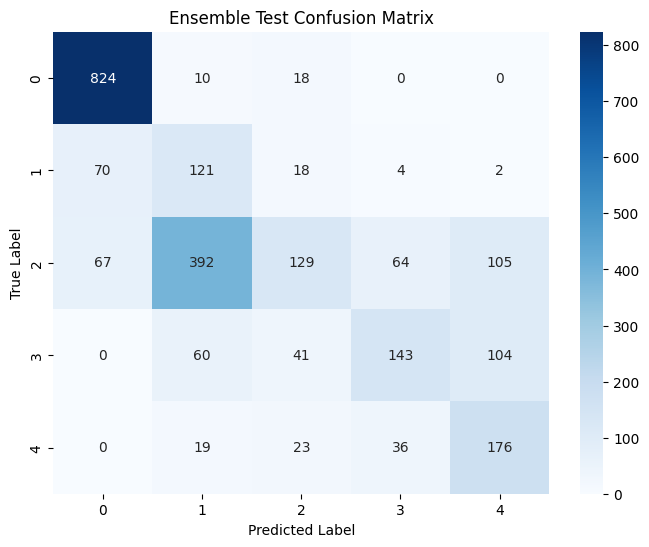

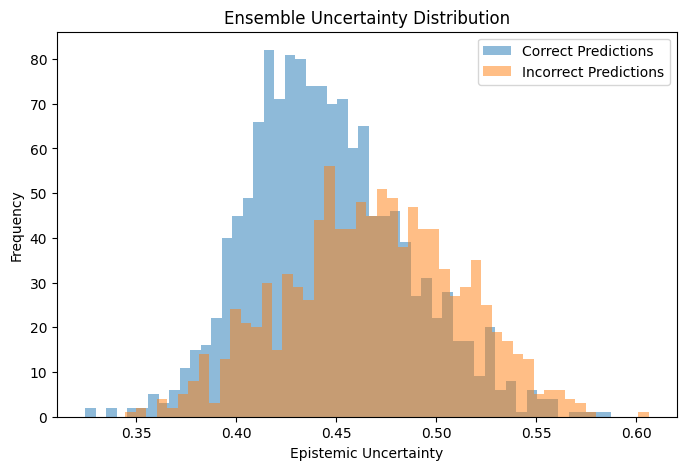

In [78]:
import glob


def load_fold_models(checkpoint_paths, device):
    ensemble_models = []
    for ckpt_path in checkpoint_paths:
        if not os.path.exists(ckpt_path):
            print(f'Skipping missing checkpoint: {ckpt_path}')
            continue
        m = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=False).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()
        ensemble_models.append(m)
    return ensemble_models


def evaluate_ensemble(models, dataloader):
    all_preds, all_labels, all_uncertainties = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Ensemble Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            alpha_sum = None
            for m in models:
                logits = m(inputs)
                alpha = softplus_evidence(logits) + 1
                alpha_sum = alpha if alpha_sum is None else alpha_sum + alpha

            alpha_avg = alpha_sum / len(models)
            S = torch.sum(alpha_avg, dim=1, keepdim=True)
            uncertainty = NUM_CLASSES / S
            _, preds = torch.max(alpha_avg, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(uncertainty.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)


# Keep off by default to preserve flow order.
USE_ENSEMBLE = True

if USE_ENSEMBLE:
    candidate_ckpts = sorted(glob.glob('best_fold_*.pth'))
    if len(candidate_ckpts) == 0:
        print('No fold checkpoints found. Run Cell 10 first with RUN_KFOLD = True.')
    else:
        print(f'Found fold checkpoints: {candidate_ckpts}')
        ensemble_models = load_fold_models(candidate_ckpts, device)

        if len(ensemble_models) == 0:
            print('No valid checkpoints could be loaded.')
        elif 'test' not in dataloaders:
            print('Test dataloader not found.')
        else:
            y_true_e, y_pred_e, u_e = evaluate_ensemble(ensemble_models, dataloaders['test'])

            acc_e = accuracy_score(y_true_e, y_pred_e)
            macro_f1_e = f1_score(y_true_e, y_pred_e, average='macro')
            weighted_f1_e = f1_score(y_true_e, y_pred_e, average='weighted')

            print(f"\nEnsemble Test Accuracy: {acc_e:.4f}")
            print(f"Ensemble Test Macro-F1: {macro_f1_e:.4f}")
            print(f"Ensemble Test Weighted-F1: {weighted_f1_e:.4f}")
            print('\nEnsemble Classification Report:')
            try:
                print(classification_report(y_true_e, y_pred_e, target_names=class_names, digits=4))
            except Exception:
                print(classification_report(y_true_e, y_pred_e, digits=4))

            cm_e = confusion_matrix(y_true_e, y_pred_e)
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.title('Ensemble Test Confusion Matrix')
            plt.show()

            plt.figure(figsize=(8, 5))
            plt.hist(u_e[y_true_e == y_pred_e], bins=50, alpha=0.5, label='Correct Predictions')
            plt.hist(u_e[y_true_e != y_pred_e], bins=50, alpha=0.5, label='Incorrect Predictions')
            plt.xlabel('Epistemic Uncertainty')
            plt.ylabel('Frequency')
            plt.legend()
            plt.title('Ensemble Uncertainty Distribution')
            plt.show()
else:
    print('Ensemble is configured. Set USE_ENSEMBLE = True after Cell 10 finishes.')

## 9. Download Checkpoints (Final Step)
Run this after training/evaluation to download `kfold_checkpoints.zip`.

In [79]:
import os
import glob
import zipfile

# Download helper for all fold checkpoints
fold_ckpts = sorted(glob.glob('best_fold_*.pth'))

if len(fold_ckpts) > 0:
    zip_path = 'kfold_checkpoints.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fp in fold_ckpts:
            zf.write(fp)
    model_path = zip_path
    print(f"Prepared archive with fold checkpoints: {fold_ckpts}")
else:
    model_path = None

if model_path is not None and os.path.exists(model_path):
    try:
        from google.colab import files
        print("Running in Google Colab. Initiating download...")
        files.download(model_path)
    except ImportError:
        from IPython.display import FileLink, display
        print("Not in Colab. Creating a universal download link...")
        display(FileLink(model_path, result_html_prefix="Click here to download: "))
else:
    print("No fold checkpoints found. Run Cell 10 first.")

Prepared archive with fold checkpoints: ['best_fold_1.pth', 'best_fold_2.pth', 'best_fold_3.pth', 'best_fold_4.pth', 'best_fold_5.pth']
Running in Google Colab. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>